# Home Credit Default Risk

## Setup

In [ ]:
try:
    import xgboost
except ImportError:
    !pip install -q xgboost

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_auc_score
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
data = pd.read_csv("application_train.csv")
df = data.copy()
print(f"Shape: {df.shape}")
df.head(3)

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
target_counts = df["TARGET"].value_counts()
positive_rate = target_counts[1] / target_counts.sum()
print(target_counts)
print(f"\nPositive class rate: {positive_rate:.2%}")
print(f"Negative-to-positive ratio: {target_counts[0] / target_counts[1]:.2f}")
print(f"\nThis model is highly imbalanced with a {1 - positive_rate:.2%} accuracy if this model always predicts 0")

TARGET
0    282686
1     24825
Name: count, dtype: int64

Positive class rate: 8.07%
Negative-to-positive ratio: 11.39

This model is highly imbalanced with a 91.93% accuracy if this model always predicts 0


## Data Cleaning

In [ ]:
#check for missing values

def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_pct = 100 * mis_val / len(df)
    table = pd.concat([mis_val, mis_val_pct], axis=1)
    table.columns = ["Missing Values", "% of Total Values"]
    table = table[table["% of Total Values"] != 0].sort_values(
        "% of Total Values", ascending=False
    ).round(1)
    print(f"{df.shape[1]} columns total, {table.shape[0]} have missing values")
    return table

missing_values_table(df).head(10)

122 columns total, 67 have missing values


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


In [ ]:
# drop columns with 50%+ missing values
df_seg1 = df.iloc[:, 1:31]
df_seg2 = df.iloc[:, 91:119]
df_dropped = pd.concat([df_seg1, df_seg2], axis=1)

# Drop a few low-utility cols
df_dropped = df_dropped.drop(
    columns=["NAME_TYPE_SUITE", "OCCUPATION_TYPE", "OWN_CAR_AGE"]
)
print(f"After dropping: {df_dropped.shape}")

After dropping: (307511, 55)


In [ ]:
#fix the DAYS_EMPLOYED outlier
n_outlier = (df_dropped["DAYS_EMPLOYED"] == 365243).sum()
print(f"Found {n_outlier} outliers in DAYS_EMPLOYED, replacing with NaN")
df_dropped["DAYS_EMPLOYED"] = df_dropped["DAYS_EMPLOYED"].replace({365243: np.nan})

# All DAYS_* columns are negative. Change to positive
for col in ["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION",
            "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"]:
    df_dropped[col] = df_dropped[col].abs()

Found 55374 outliers in DAYS_EMPLOYED, replacing with NaN


In [ ]:
df_dropped["CREDIT_INCOME_PERCENT"] = (
    df_dropped["AMT_CREDIT"] / df_dropped["AMT_INCOME_TOTAL"]
).round(2)
df_dropped["ANNUITY_INCOME_PERCENT"] = (
    df_dropped["AMT_ANNUITY"] / df_dropped["AMT_INCOME_TOTAL"]
).round(2)
df_dropped["GOODS_INCOME_PERCENT"] = (
    df_dropped["AMT_GOODS_PRICE"] / df_dropped["AMT_INCOME_TOTAL"]
).round(2)

print(f"Final shape: {df_dropped.shape}")

Final shape: (307511, 58)


## Train / validation / test split

In [ ]:
X = df_dropped.drop("TARGET", axis=1)
y = df_dropped["TARGET"].astype(int)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Stratified split so each fold has the same 8% positive rate
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):>6}  positive rate: {y_train.mean():.3f}")
print(f"Valid: {len(X_valid):>6}  positive rate: {y_valid.mean():.3f}")
print(f"Test:  {len(X_test):>6}  positive rate: {y_test.mean():.3f}")

Train: 215257  positive rate: 0.081
Valid:  46127  positive rate: 0.081
Test:   46127  positive rate: 0.081


## Preprocessing pipeline

In [ ]:
num_proc = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

cat_proc = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_proc, num_cols),
        ("cat", cat_proc, cat_cols),
    ],
    remainder="drop",
).set_output(transform="pandas")

## Metrics report functions


In [ ]:
def report_metrics(name, y_true, y_pred, y_proba):
    metrics = {
        "Accuracy":   accuracy_score(y_true, y_pred),
        "Precision":  precision_score(y_true, y_pred, zero_division=0),
        "Recall":     recall_score(y_true, y_pred, zero_division=0),
        "F1":         f1_score(y_true, y_pred, zero_division=0),
        "AUCPR":      average_precision_score(y_true, y_proba),
        "AUC-ROC":    roc_auc_score(y_true, y_proba),
    }
    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    return metrics

def plot_confusion_and_pr(name, y_true, y_pred, y_proba):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"{name} — Confusion Matrix")

    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    axes[1].plot(rec, prec, lw=2)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{name} — PR curve (AP = {ap:.3f})")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## Decision Tree

In [ ]:
dt_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(
        criterion="gini",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

dt_grid = {
    "clf__max_depth":         [4, 6, 8, 10],
    "clf__min_samples_split": [2, 10, 50],
    "clf__min_samples_leaf":  [1, 20, 50],
}

dt_search = GridSearchCV(
    dt_pipe,
    param_grid=dt_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
dt_search.fit(X_train, y_train)
print("Best params:", dt_search.best_params_)
print(f"CV AUCPR: {dt_search.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'clf__max_depth': 8, 'clf__min_samples_leaf': 50, 'clf__min_samples_split': 2}
CV AUCPR: 0.1323


=== Decision Tree (TEST) ===
  Accuracy  : 0.6080
  Precision : 0.1181
  Recall    : 0.5959
  F1        : 0.1971
  AUCPR     : 0.1287
  AUC-ROC   : 0.6360


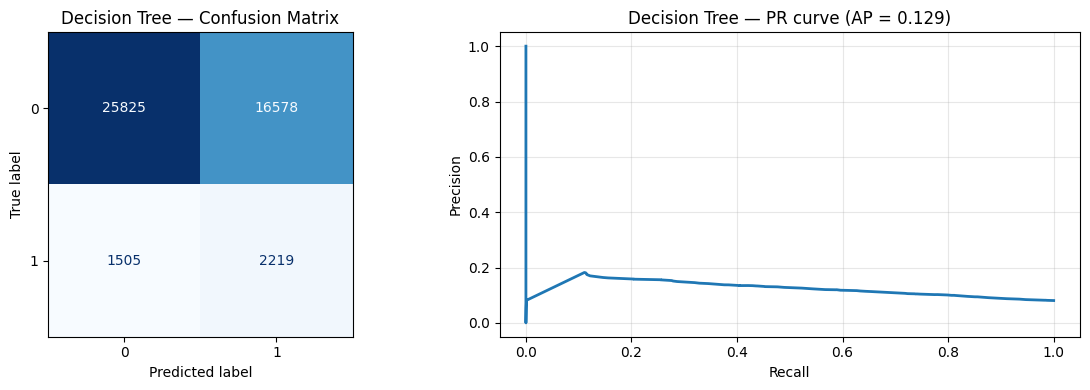

In [ ]:
dt_best = dt_search.best_estimator_
y_test_pred  = dt_best.predict(X_test)
y_test_proba = dt_best.predict_proba(X_test)[:, 1]

dt_metrics = report_metrics("Decision Tree (TEST)", y_test, y_test_pred, y_test_proba)
plot_confusion_and_pr("Decision Tree", y_test, y_test_pred, y_test_proba)

## Gradient Boosting

In [ ]:
hgb_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", HistGradientBoostingClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

hgb_grid = {
    "clf__learning_rate":  [0.05, 0.1],
    "clf__max_depth":      [None, 6, 10],
    "clf__max_iter":       [200, 400],
}

hgb_search = GridSearchCV(
    hgb_pipe,
    param_grid=hgb_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
hgb_search.fit(X_train, y_train)
print("Best params:", hgb_search.best_params_)
print(f"CV AUCPR: {hgb_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__max_iter': 200}
CV AUCPR: 0.1724


=== HistGradientBoosting (TEST) ===
  Accuracy  : 0.6841
  Precision : 0.1461
  Recall    : 0.6012
  F1        : 0.2351
  AUCPR     : 0.1744
  AUC-ROC   : 0.6968


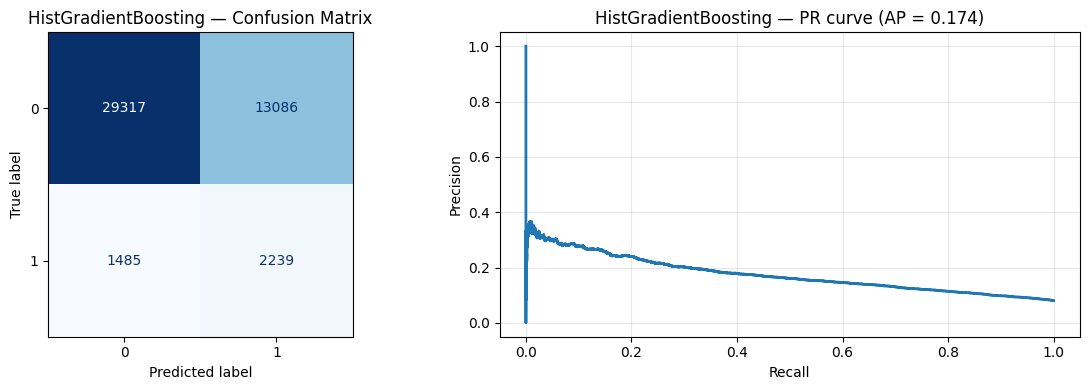

In [ ]:
hgb_best = hgb_search.best_estimator_
y_test_pred  = hgb_best.predict(X_test)
y_test_proba = hgb_best.predict_proba(X_test)[:, 1]

hgb_metrics = report_metrics("HistGradientBoosting (TEST)", y_test, y_test_pred, y_test_proba)
plot_confusion_and_pr("HistGradientBoosting", y_test, y_test_pred, y_test_proba)

## XGBoost

In [ ]:
# Compute imbalance ratio from training set only
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {neg} / {pos} = {spw:.2f}")

# Preprocess once outside the model so we can use early stopping cleanly
preprocess.fit(X_train, y_train)
Xtr = preprocess.transform(X_train)
Xva = preprocess.transform(X_valid)
Xte = preprocess.transform(X_test)

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    random_state=RANDOM_STATE,
    tree_method="hist",
    eval_metric="aucpr",
    early_stopping_rounds=50,
)

xgb.fit(
    Xtr, y_train,
    eval_set=[(Xtr, y_train), (Xva, y_valid)],
    verbose=False,
)
print(f"Stopped at iteration: {xgb.best_iteration + 1}")

scale_pos_weight = 197880 / 17377 = 11.39
Stopped at iteration: 335


=== XGBoost (TEST, threshold=0.5) ===
  Accuracy  : 0.6787
  Precision : 0.1452
  Recall    : 0.6096
  F1        : 0.2345
  AUCPR     : 0.1769
  AUC-ROC   : 0.6978


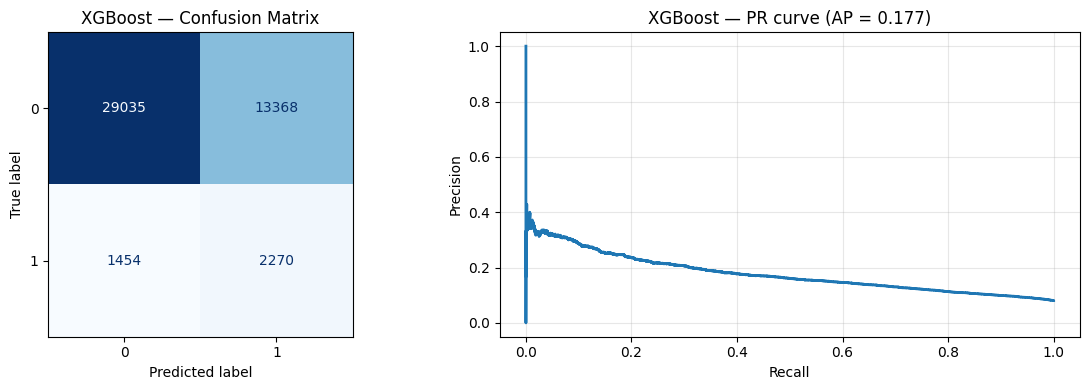

In [ ]:
y_test_pred  = xgb.predict(Xte)
y_test_proba = xgb.predict_proba(Xte)[:, 1]

xgb_metrics = report_metrics("XGBoost (TEST, threshold=0.5)", y_test, y_test_pred, y_test_proba)
plot_confusion_and_pr("XGBoost", y_test, y_test_pred, y_test_proba)

## Threshold tuning on the validation set

Best threshold (max F1 on valid): 0.5997
  -> Valid precision: 0.1852
  -> Valid recall:    0.4117
  -> Valid F1:        0.2555
=== XGBoost (TEST, threshold=0.600) ===
  Accuracy  : 0.8054
  Precision : 0.1794
  Recall    : 0.3947
  F1        : 0.2467
  AUCPR     : 0.1769
  AUC-ROC   : 0.6978


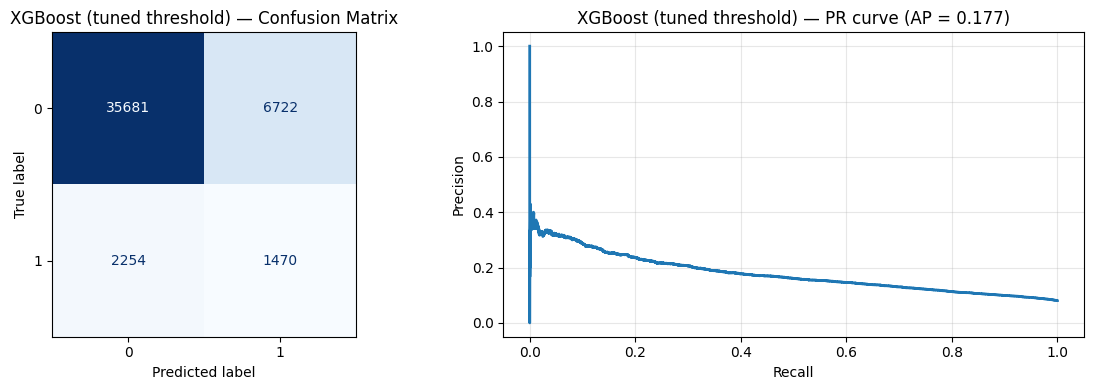

In [ ]:
y_valid_proba = xgb.predict_proba(Xva)[:, 1]
prec, rec, thresh = precision_recall_curve(y_valid, y_valid_proba)

# precision_recall_curve returns one less threshold than prec/rec entries
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_thresh = thresh[best_idx]

print(f"Best threshold (max F1 on valid): {best_thresh:.4f}")
print(f"  -> Valid precision: {prec[best_idx]:.4f}")
print(f"  -> Valid recall:    {rec[best_idx]:.4f}")
print(f"  -> Valid F1:        {f1_scores[best_idx]:.4f}")

# Apply tuned threshold on test
y_test_pred_tuned = (y_test_proba >= best_thresh).astype(int)
xgb_tuned_metrics = report_metrics(
    f"XGBoost (TEST, threshold={best_thresh:.3f})",
    y_test, y_test_pred_tuned, y_test_proba,
)
plot_confusion_and_pr("XGBoost (tuned threshold)", y_test, y_test_pred_tuned, y_test_proba)

## XGBoost feature importances

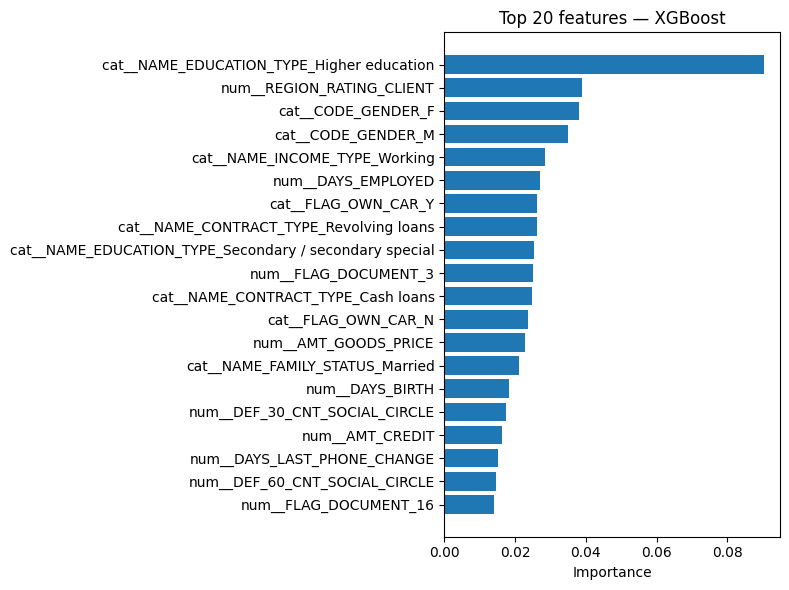

In [ ]:
feat_names = preprocess.get_feature_names_out()
importances = xgb.feature_importances_
top = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8, 6))
plt.barh(np.array(feat_names)[top][::-1], importances[top][::-1])
plt.xlabel("Importance")
plt.title("Top 20 features — XGBoost")
plt.tight_layout()
plt.show()

## Final comparison

In [ ]:
summary = pd.DataFrame([
    {"Model": "Decision Tree",     **dt_metrics},
    {"Model": "HistGradientBoost", **hgb_metrics},
    {"Model": "XGBoost (t=0.5)",   **xgb_metrics},
    {"Model": "XGBoost (tuned)",   **xgb_tuned_metrics},
])
display(summary.round(4))

,Model,Accuracy,Precision,Recall,F1,AUCPR,AUC-ROC
0,Decision Tree,0.6080,0.1181,0.5959,0.1971,0.1287,0.6360
1,HistGradientBoost,0.6841,0.1461,0.6012,0.2351,0.1744,0.6968
2,XGBoost (t=0.5),0.6787,0.1452,0.6096,0.2345,0.1769,0.6978
3,XGBoost (tuned),0.8054,0.1794,0.3947,0.2467,0.1769,0.6978


## Analysis

### a. Why boosting methods improve generalization

A single decision tree has to commit to one global partition of the feature space. If that partition is wrong in some regions, there's no mechanism to correct it. Boosting fixes this by training trees sequentially, where each new tree is fit to the residual errors of the current ensemble. Three things drive the generalization gain:

1. **Error correction:** Tree *t+1* focuses specifically on examples the ensemble at step *t* gets wrong, so the ensemble keeps reducing training error in the regions where it currently struggles.
2. **Shallow base learners:** Each tree is intentionally weak. Individually they have high bias and low variance. The ensemble lowers bias through aggregation without inheriting the variance of a single deep tree.
3. **Learning rate:** Each tree's contribution is scaled down by the learning rate (0.1 in HistGB, 0.05 in XGB). This forces the ensemble to take many small steps instead of a few big ones, which empirically generalizes better.

The results show this clearly: the single Decision Tree got AUCPR 0.129, HistGB got 0.174, and XGBoost got 0.177. That's a ~37% relative lift in ranking quality going from one tree to a boosted ensemble, holding everything else (preprocessing, class weighting, scoring metric) constant.

### b. Bias–variance trade-off

The Decision Tree's grid search picked `max_depth=8`, HistGB picked `max_depth=6` with `max_iter=200`, and XGBoost converged at 335 iterations under early stopping. None of these landed at the extremes of their respective grids, which suggests the search settled in a reasonable bias-variance region rather than under- or over-fitting.

The trade-off is also visible in XGBoost's early stopping behavior: training proceeded for 335 rounds before validation AUCPR stopped improving for 50 consecutive rounds. That's the regularization sweet spot — past that point, additional trees would just memorize training noise without helping on held-out data.

The remaining gap — AUC-ROC 0.70 and AUCPR 0.18 — is not mainly variance. Top Kaggle solutions on Home Credit reach ~0.80 AUC-ROC, but they do it by joining the bureau, previous_application, POS_CASH, and installments tables. That extra information is missing from this pipeline, so the residual error is mostly **bias from missing features**, not variance from overfitting.

### c. Computational cost and interpretability

| Model | Training time (rough) | Interpretability |
|---|---|---|
| Decision Tree | seconds | Highest — can visualize the tree, follow decision paths exactly |
| HistGradientBoosting | minutes | Medium — feature importance is meaningful; individual trees not human-readable |
| XGBoost | minutes | Medium — same as HistGB |

The interpretability cost is real but recoverable. A boosted model with 200+ trees of depth 5–6 is not something a human can trace, but two tools partially close the gap: **feature importance** gives a global view of which features the model relies on, and **SHAP values** give per-prediction explanations of how each feature pushed the score up or down. For credit decisions that need to be explained to applicants or regulators, SHAP would be the next thing to add.

### d. How feature importance helps interpret predictions

The XGBoost feature importance plot shows the model relies most heavily on, in order: education level, `REGION_RATING_CLIENT`, gender, employment status (`NAME_INCOME_TYPE_Working`, `DAYS_EMPLOYED`), and asset/loan structure (`FLAG_OWN_CAR_Y`, `NAME_CONTRACT_TYPE_Revolving loans`, `AMT_GOODS_PRICE`, `AMT_CREDIT`).

This tells me the model is leaning on socioeconomic and demographic signals that match domain intuition: education level is one of the strongest correlates of income stability in real credit data, region rating is essentially a geographic risk score baked into the dataset, and employment type and job tenure relate directly to repayment ability. It's a sanity check — if the top features had been things like `FLAG_DOCUMENT_2` or random ID-like columns, I'd suspect the pipeline was broken or leaking.

A few things I learned about reading feature importance:

- **No direction of effect.** Importance tells me education matters, but not whether higher or lower education increases default risk. SHAP values would show the sign per prediction.
- **No causality.** Education being predictive doesn't mean education *causes* repayment behavior. It correlates with income, region, and employment type, all of which the model is also using. The features are not independent.
- **Instability across models.** The Decision Tree concentrated importance heavily on `DAYS_EMPLOYED` and `NAME_EDUCATION_TYPE_Higher education`, while XGBoost spreads importance more evenly across 15+ features. That's expected (boosting uses more features per tree) but it means "feature importance" isn't one universal ranking.

### Interpretation of findings

The three models converge on similar conclusions:

| Model | AUCPR | AUC-ROC | F1 | Recall |
|---|---|---|---|---|
| Decision Tree | 0.129 | 0.636 | 0.197 | 0.596 |
| HistGradientBoosting | 0.174 | 0.697 | 0.235 | 0.601 |
| XGBoost (t=0.5) | 0.177 | 0.698 | 0.235 | 0.610 |
| XGBoost (tuned t=0.60) | 0.177 | 0.698 | 0.247 | 0.395 |

Two takeaways. First, the boosted models are consistently and meaningfully better than the single tree across every metric — boosting helped. Second, threshold tuning is a separate decision from model choice: at threshold 0.5, XGBoost catches 2,270 of 3,724 defaulters (61% recall) at the cost of flagging 13,368 non-defaulters (precision 14.5%). At the F1-tuned threshold of 0.60, the model catches 1,470 defaulters (39% recall) and flags 6,722 non-defaulters (precision 17.9%), and accuracy jumps to 80.5%. Same model, same probability scores, just a different cutoff. The choice between these is a business question, not a statistics question.

In credit scoring, this trade-off *is* the business decision. A bank that wants to minimize losses will tolerate many false positives to catch defaulters; a bank that wants to maximize loan volume will tolerate missed defaulters to approve more applicants. The model gives them a probability score — they choose the threshold based on cost.

### Limitations

1. **Class imbalance handled via reweighting only.** I didn't compare against SMOTE, undersampling, or focal loss. Different methods can give different precision-recall trade-offs.
2. **Minimal feature engineering.** I added three ratio features but ran out of ideas for more. I believe there are more options for feature engineering that could help the model train better.
3. **Random seeds.** All splits and model fits use a single random seed. A more rigorous evaluation would average results across multiple seeds to confirm the AUCPR ≈ 0.18 ceiling isn't seed-dependent.

### Bias–variance reflection

The cleanest lesson from this project is that **bias can hide behind the wrong metric**. Accuracy on an 8% positive class can look excellent while the model is actually ignoring the positive class entirely, so the choice of evaluation metric (AUCPR here) is what makes the bias problem visible in the first place. Once visible, variance is controlled through standard regularization — early stopping, max_depth, min_samples_leaf, subsampling. The remaining performance gap is bias from missing tables, not variance from overfitting, so adding data would help more than further tuning.